# Mitigation Analysis — priority intersections

Detailed **crash-reason** and **KABCO injury-severity** breakdowns for the intersections flagged for mitigation, grouped by **priority**. Source: crashes at or near an intersection — `INTERSECTION_RELATED_I` is `Y` **or blank** (everything except the explicit `N`s) — in the 27th Ward, each assigned to its nearest ward intersection.

Several targets are **intersection *systems*** — diagonal/offset junctions (e.g. Ogden) and split streets (e.g. Randolph N/S) appear as several nearby nodes that function as one intersection, so we aggregate their crashes.

| priority | intersections |
|---|---|
| **High** | N Kedzie & W Chicago · Western & Madison · S Leavitt & W Van Buren · S Paulina & W Roosevelt |
| **Medium** | W Congress & Ogden (+ Wolcott) · S Marshfield & W Taylor · N Morgan & Randolph (N+S) |

**KABCO scale:** K = fatal, A = incapacitating, B = non-incapacitating (evident), C = possible, O = no injury.

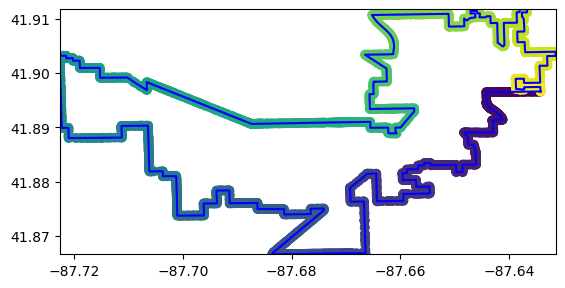

43,730 crashes (Y or blank) across 1002 ward intersections


In [1]:
import pandas as pd, numpy as np, geopandas as gpd
import matplotlib.pyplot as plt
from shapely import wkt
from coordinate_to_ward import *
from street_intersections import *

our_ward = ward_shape(27)
all_crashes = pd.read_csv('Traffic_Crashes_-_Crashes_20260622.csv', low_memory=False).dropna(subset=['LOCATION'])
all_crashes['LOCATION'] = all_crashes['LOCATION'].apply(wkt.loads)
all_crashes = gpd.GeoDataFrame(all_crashes, geometry='LOCATION', crs='EPSG:4326')
# Mitigation analysis uses the BROADER set: at-or-near an intersection = Y or blank (exclude only explicit 'N').
near_intersection = all_crashes[all_crashes.LOCATION.within(our_ward)
                                & (all_crashes['INTERSECTION_RELATED_I'] != 'N')].copy()

# Ward intersections (from street centrelines) + nearest-intersection assignment for each crash.
ints = intersections.reset_index().dropna(subset=['lon', 'lat'])
ward_intersections = gpd.GeoDataFrame(ints, geometry=gpd.points_from_xy(ints.lon, ints.lat), crs='EPSG:4326')
ward_intersections = ward_intersections[ward_intersections.within(our_ward)].reset_index(drop=True)
assigned = gpd.sjoin_nearest(near_intersection.to_crs(3435), ward_intersections.to_crs(3435)[['geometry']])
assigned = assigned[~assigned.index.duplicated(keep='first')]   # one nearest intersection per crash

# KABCO severity columns + comprehensive injury cost (NSC).
KABCO = [('K', 'INJURIES_FATAL'), ('A', 'INJURIES_INCAPACITATING'), ('B', 'INJURIES_NON_INCAPACITATING'),
         ('C', 'INJURIES_REPORTED_NOT_EVIDENT'), ('O', 'INJURIES_NO_INDICATION')]
KABCO_COST = {'K': 2_050_000, 'A': 174_000, 'B': 45_000, 'C': 28_000, 'O': 7_700}
print(f'{len(near_intersection):,} crashes (Y or blank) across {len(ward_intersections)} ward intersections')

In [2]:
# Priority groups. Each intersection is a SYSTEM = the union of ward nodes matching any street-keyword
# pair (so multi-node diagonal/offset junctions are combined).
PRIORITY = {
    'High': {
        'N Kedzie Ave & W Chicago Ave':    [('KEDZIE', 'CHICAGO')],
        'Western & Madison':               [('WESTERN', 'MADISON')],
        'S Leavitt St & W Van Buren St':   [('LEAVITT', 'VAN BUREN')],
        'S Paulina St & W Roosevelt Rd':   [('PAULINA', 'ROOSEVELT')],
    },
    'Medium': {
        'W Congress Pkwy & W Ogden Ave (+ Wolcott)': [('CONGRESS', 'OGDEN'), ('WOLCOTT', 'CONGRESS'), ('WOLCOTT', 'OGDEN')],
        'S Marshfield Ave & W Taylor St':            [('MARSHFIELD', 'TAYLOR')],
        'N Morgan St & W Randolph St (N+S)':         [('MORGAN', 'RANDOLPH')],
    },
}

def system_nodes(pairs):
    idx = set()
    for a, b in pairs:
        m = (ward_intersections['streets'].str.contains(a, case=False, na=False)
             & ward_intersections['streets'].str.contains(b, case=False, na=False))
        idx |= set(ward_intersections.index[m])
    return sorted(idx)

systems = []   # one entry per intersection system, in priority order (High then Medium)
for priority, items in PRIORITY.items():
    for name, pairs in items.items():
        nodes = system_nodes(pairs)
        systems.append({'priority': priority, 'name': name, 'nodes': nodes,
                        'streets': ' | '.join(ward_intersections.loc[nodes, 'streets']),
                        'crashes': assigned[assigned['index_right'].isin(nodes)]})

def kabco_counts(c):
    return {k: int(c[col].fillna(0).sum()) for k, col in KABCO}

for s in systems:
    print(f"[{s['priority']:6}] {s['name']:44} nodes={s['nodes']}  crashes={len(s['crashes'])}")

[High  ] N Kedzie Ave & W Chicago Ave                 nodes=[727]  crashes=456
[High  ] Western & Madison                            nodes=[917]  crashes=521
[High  ] S Leavitt St & W Van Buren St                nodes=[319]  crashes=52
[High  ] S Paulina St & W Roosevelt Rd                nodes=[314]  crashes=213
[Medium] W Congress Pkwy & W Ogden Ave (+ Wolcott)    nodes=[589, 829, 936]  crashes=372
[Medium] S Marshfield Ave & W Taylor St               nodes=[563]  crashes=154
[Medium] N Morgan St & W Randolph St (N+S)            nodes=[119, 125, 652]  crashes=149


In [3]:
# Summary table, grouped by priority.
rows = []
for s in systems:
    c = s['crashes']; kc = kabco_counts(c)
    rows.append({'priority': s['priority'], 'intersection': s['name'], 'crashes': len(c),
                 **kc, 'injured (K-C)': kc['K'] + kc['A'] + kc['B'] + kc['C'],
                 'injury_cost': sum(kc[k] * KABCO_COST[k] for k in kc),
                 'top_crash_type': c['FIRST_CRASH_TYPE'].mode().iat[0] if len(c) else '',
                 'top_cause': c['PRIM_CONTRIBUTORY_CAUSE'].mode().iat[0] if len(c) else ''})
summary = pd.DataFrame(rows)
summary_fmt = summary.copy()
summary_fmt['injury_cost'] = summary_fmt['injury_cost'].map('${:,.0f}'.format)
summary_fmt

,priority,intersection,crashes,K,A,B,C,O,injured (K-C),injury_cost,top_crash_type,top_cause
0,High,N Kedzie Ave & W Chicago Ave,456,3,10,58,45,961,116,"$19,159,700",PARKED MOTOR VEHICLE,UNABLE TO DETERMINE
1,High,Western & Madison,521,0,13,53,19,1033,85,"$13,133,100",PARKED MOTOR VEHICLE,UNABLE TO DETERMINE
2,High,S Leavitt St & W Van Buren St,52,0,4,24,9,98,37,"$2,782,600",ANGLE,UNABLE TO DETERMINE
3,High,S Paulina St & W Roosevelt Rd,213,0,7,19,22,502,48,"$6,554,400",REAR END,UNABLE TO DETERMINE
4,Medium,W Congress Pkwy & W Ogden Ave (+ Wolcott),372,0,12,64,42,885,118,"$12,958,500",ANGLE,FAILING TO YIELD RIGHT-OF-WAY
5,Medium,S Marshfield Ave & W Taylor St,154,0,2,31,13,365,46,"$4,917,500",TURNING,UNABLE TO DETERMINE
6,Medium,N Morgan St & W Randolph St (N+S),149,1,2,14,3,299,20,"$5,414,300",PARKED MOTOR VEHICLE,UNABLE TO DETERMINE


In [4]:
# Detailed breakdown for one intersection system: KABCO injuries + crash reason.
def detail(s, top=6):
    c = s['crashes']; kc = kabco_counts(c); cost = sum(kc[k] * KABCO_COST[k] for k in kc)
    print('=' * 92)
    print(f"{s['priority'].upper()}  |  {s['name']}   ({len(c)} crashes)")
    print(f"nodes {s['nodes']}: {s['streets']}")
    print('\nKABCO injury breakdown (persons):  ' + '   '.join(f'{k}={kc[k]}' for k, _ in KABCO))
    print(f'comprehensive injury cost: ${cost:,.0f}')
    print('\nCrash type (FIRST_CRASH_TYPE), % of crashes:')
    print((c['FIRST_CRASH_TYPE'].value_counts(normalize=True).head(top) * 100).round(1).to_string())
    print('\nPrimary contributory cause, % of crashes:')
    print((c['PRIM_CONTRIBUTORY_CAUSE'].value_counts(normalize=True).head(top) * 100).round(1).to_string())

def detail_group(priority):
    for s in systems:
        if s['priority'] == priority:
            detail(s); print()

## High-priority intersections

In [5]:
detail_group('High')

HIGH  |  N Kedzie Ave & W Chicago Ave   (456 crashes)
nodes [727]: N KEDZIE AVE & W CHICAGO AVE

KABCO injury breakdown (persons):  K=3   A=10   B=58   C=45   O=961
comprehensive injury cost: $19,159,700

Crash type (FIRST_CRASH_TYPE), % of crashes:
FIRST_CRASH_TYPE
PARKED MOTOR VEHICLE        20.6
TURNING                     16.9
ANGLE                       16.4
REAR END                    15.6
SIDESWIPE SAME DIRECTION    11.0
PEDESTRIAN                   6.1

Primary contributory cause, % of crashes:
PRIM_CONTRIBUTORY_CAUSE
UNABLE TO DETERMINE                       43.2
FAILING TO YIELD RIGHT-OF-WAY              9.9
FOLLOWING TOO CLOSELY                      7.0
IMPROPER BACKING                           5.7
IMPROPER OVERTAKING/PASSING                4.4
FAILING TO REDUCE SPEED TO AVOID CRASH     4.4

HIGH  |  Western & Madison   (521 crashes)
nodes [917]: N WESTERN AVE & S WESTERN AVE & W MADISON ST

KABCO injury breakdown (persons):  K=0   A=13   B=53   C=19   O=1033
comprehensive 

## Medium-priority intersections

In [6]:
detail_group('Medium')

MEDIUM  |  W Congress Pkwy & W Ogden Ave (+ Wolcott)   (372 crashes)
nodes [589, 829, 936]: W CONGRESS PKWY & W OGDEN AVE | S WOLCOTT AVE & W CONGRESS PKWY | S WOLCOTT AVE & W OGDEN AVE

KABCO injury breakdown (persons):  K=0   A=12   B=64   C=42   O=885
comprehensive injury cost: $12,958,500

Crash type (FIRST_CRASH_TYPE), % of crashes:
FIRST_CRASH_TYPE
ANGLE                       72.6
TURNING                      9.1
REAR END                     6.5
SIDESWIPE SAME DIRECTION     4.6
HEAD ON                      2.4
PEDALCYCLIST                 1.3

Primary contributory cause, % of crashes:
PRIM_CONTRIBUTORY_CAUSE
FAILING TO YIELD RIGHT-OF-WAY                           50.0
UNABLE TO DETERMINE                                     28.8
DISREGARDING STOP SIGN                                   7.5
FOLLOWING TOO CLOSELY                                    3.8
VISION OBSCURED (SIGNS, TREE LIMBS, BUILDINGS, ETC.)     2.4
FAILING TO REDUCE SPEED TO AVOID CRASH                   2.2

MEDIUM  |  

## Visual summary

Two views across all seven systems (ordered High → Medium): the **injury-severity profile** (injured persons K/A/B/C; the "O = no injury" majority is excluded so severity is visible) and the **crash-type composition** (share of each crash's `FIRST_CRASH_TYPE`).

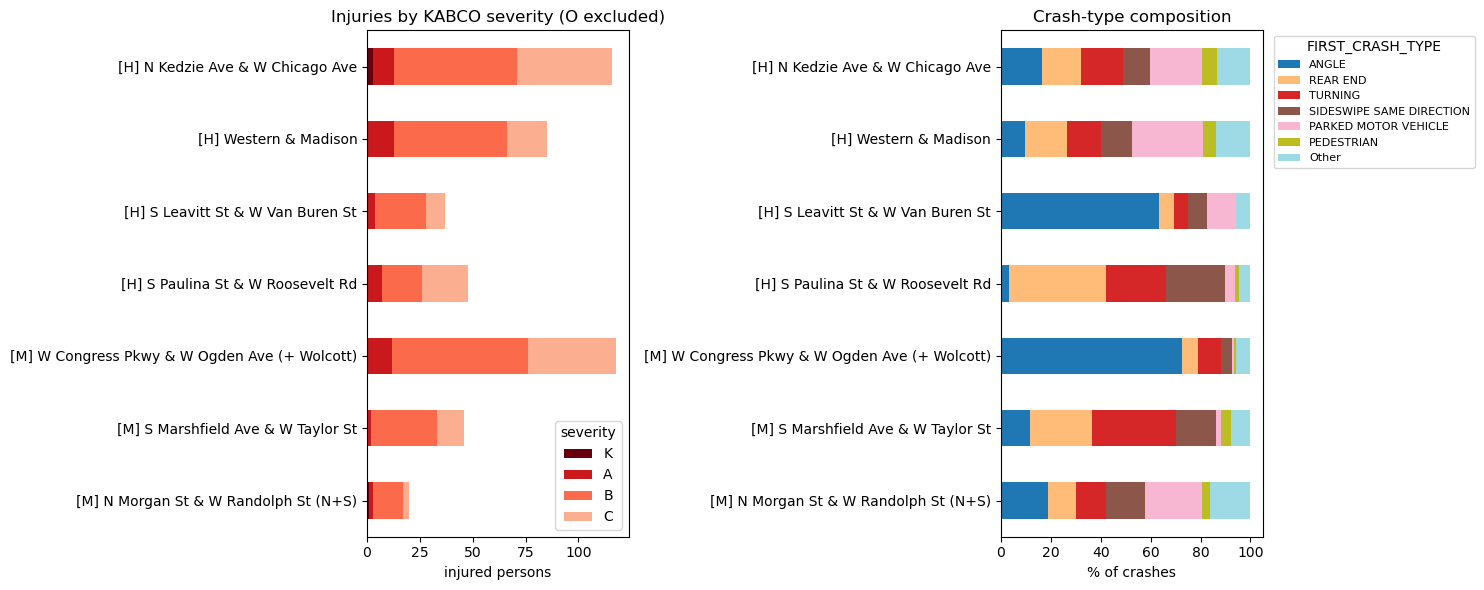

In [7]:
labels = [f"[{'H' if s['priority']=='High' else 'M'}] {s['name']}" for s in systems]

# 1) Injured persons by KABCO severity (exclude O so the severe categories are visible).
kdf = pd.DataFrame([{k: kabco_counts(s['crashes'])[k] for k in ['K', 'A', 'B', 'C']} for s in systems], index=labels)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
kdf.plot(kind='barh', stacked=True, ax=ax1, color=['#67000d', '#cb181d', '#fb6a4a', '#fcae91'])
ax1.invert_yaxis(); ax1.set_xlabel('injured persons'); ax1.set_title('Injuries by KABCO severity (O excluded)')
ax1.legend(title='severity', loc='lower right')

# 2) Crash-type composition (top types + Other).
comp = pd.DataFrame({s['name']: s['crashes']['FIRST_CRASH_TYPE'].value_counts(normalize=True) for s in systems}).T.fillna(0) * 100
topcols = comp.sum().sort_values(ascending=False).head(6).index.tolist()
comp2 = comp[topcols].copy(); comp2['Other'] = (100 - comp2.sum(axis=1)).clip(lower=0)
comp2.index = labels
comp2.plot(kind='barh', stacked=True, ax=ax2, colormap='tab20')
ax2.invert_yaxis(); ax2.set_xlabel('% of crashes'); ax2.set_title('Crash-type composition')
ax2.legend(title='FIRST_CRASH_TYPE', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout(); plt.show()

## Crash reason by intersection

Composition of each crash's **primary contributory cause** (`PRIM_CONTRIBUTORY_CAUSE`) per intersection system, ordered High → Medium. (`UNABLE TO DETERMINE` is kept as reported — it's a large non-actionable bucket, so read the *other* segments for the mitigable causes.)

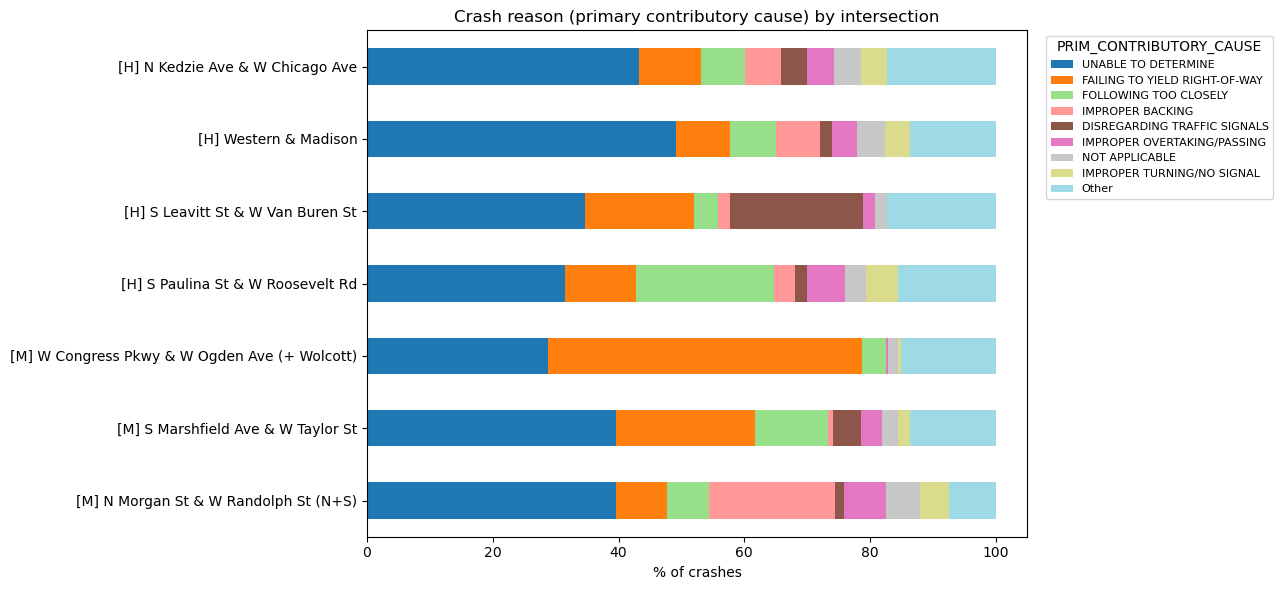

In [8]:
# Crash REASON (primary contributory cause) composition per intersection.
labels = [f"[{'H' if s['priority'] == 'High' else 'M'}] {s['name']}" for s in systems]
cause = pd.DataFrame({s['name']: s['crashes']['PRIM_CONTRIBUTORY_CAUSE'].value_counts(normalize=True)
                      for s in systems}).T.fillna(0) * 100
topc = cause.sum().sort_values(ascending=False).head(8).index.tolist()   # most common causes across these sites
cc = cause[topc].copy(); cc['Other'] = (100 - cc.sum(axis=1)).clip(lower=0)
cc.index = labels

ax = cc.plot(kind='barh', stacked=True, figsize=(13, 6), colormap='tab20')
ax.invert_yaxis(); ax.set_xlabel('% of crashes')
ax.set_title('Crash reason (primary contributory cause) by intersection')
ax.legend(title='PRIM_CONTRIBUTORY_CAUSE', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout(); plt.show()

## Worst vs. average vs. best — crash-profile comparison

A reference baseline for the priority sites: we compare three pooled crash profiles —
- **Priority (mitigation) sites** — the seven systems above,
- **All intersections** — the ward average,
- **Safer-than-expected** — intersections whose context-model factor is **≤ 0.5** (fewer than half the crashes their volume / junction size / density / crime predict).

"Safer-than-expected" is defined by the context screening model from `Crash_Analysis` (Negative-Binomial on `Y`-only intersection crashes), which we rebuild here. All three crash *profiles* use this notebook's broader `Y`-or-blank crash set, so they're directly comparable.

In [9]:
# Rebuild the context-only screening factor (Y-only model from Crash_Analysis) to flag safer sites.
import statsmodels.formula.api as smf, statsmodels.api as sm
intersection_related = all_crashes[all_crashes.LOCATION.within(our_ward)
                                   & (all_crashes['INTERSECTION_RELATED_I'] == 'Y')].copy()
wi3435 = ward_intersections.to_crs(3435)
cmin = int(pd.to_datetime(all_crashes['CRASH_DATE']).min().year)
ward_3435 = gpd.GeoSeries([our_ward], crs='EPSG:4326').to_crs(3435).iloc[0]

# entering AADT (surface roads only) per intersection
aadt = gpd.read_file('idot_aadt/Annual_Average_Daily_Traffic_(AADT).geojson').to_crs(3435)
aadt = aadt[aadt.intersects(ward_3435)]
ex = aadt['ROAD_NAME'].str.contains('Expwy|Ramp| to I| EB| WB| NB| SB|CD ', case=False, na=False) | aadt['MARKED_NAM'].str.match(r'I\d', na=False)
surf = aadt[~ex].copy(); surf['road'] = surf['ROAD_NAME'].str.upper().str.strip()
ab = wi3435[['geometry']].copy(); ab['geometry'] = ab.buffer(100); ab['iid'] = ab.index
entering = gpd.sjoin(ab, surf[['road', 'AADT', 'geometry']], predicate='intersects').groupby(['iid', 'road'])['AADT'].max().groupby('iid').sum()

# census density + violent-crime rate per intersection
blocks = gpd.read_file('census/tl_2020_17_tabblock20.zip', bbox=tuple(our_ward.bounds)).to_crs('EPSG:4326')
blocks = blocks[blocks.intersects(our_ward)].copy(); blocks['POP20'] = blocks['POP20'].astype(int)
blocks['density'] = np.where(blocks['ALAND20'] > 0, blocks['POP20'] / (blocks['ALAND20'] / 1e6), 0)
b50 = wi3435[['geometry']].copy(); b50['geometry'] = b50.buffer(50); b50['iid'] = b50.index
dens = gpd.sjoin(b50, blocks[['density', 'geometry']].to_crs(3435), predicate='intersects').groupby('iid')['density'].mean()
crime = pd.read_csv('crime/ijzp-q8t2.csv', usecols=['primary_type', 'year', 'latitude', 'longitude'], low_memory=False)
crime = crime[crime['primary_type'].isin(['HOMICIDE', 'ASSAULT', 'BATTERY']) & (crime['year'] >= cmin)].dropna(subset=['latitude', 'longitude'])
cg = gpd.GeoDataFrame(crime, geometry=gpd.points_from_xy(crime.longitude, crime.latitude), crs='EPSG:4326')
cg = cg[cg.within(our_ward)].to_crs(3435)
b500 = wi3435[['geometry']].copy(); b500['geometry'] = b500.buffer(500); b500['iid'] = b500.index
crime_by_int = gpd.sjoin(b500, cg[['geometry']], predicate='intersects').groupby('iid').size()
blk = blocks[['POP20', 'geometry']].to_crs(3435).copy(); blk['blk_area'] = blk.geometry.area
ovl = gpd.overlay(b500[['iid', 'geometry']], blk, how='intersection'); ovl['pop'] = ovl['POP20'] * (ovl.geometry.area / ovl['blk_area'])
pop_by_int = ovl.groupby('iid')['pop'].sum(); POP_FLOOR = float(pop_by_int[pop_by_int > 0].quantile(.05))

# per-node Y-only counts + features -> NB -> Empirical-Bayes factor
nnY = gpd.sjoin_nearest(intersection_related.to_crs(3435), wi3435[['geometry']]); nnY = nnY[~nnY.index.duplicated(keep='first')]
f = pd.DataFrame({'n_crashes': nnY.groupby('index_right').size()})
f['num_streets'] = ward_intersections['num_streets'].astype(float)
f['entering_aadt'] = f.index.map(entering)
f['crime'] = f.index.map(crime_by_int).fillna(0)
f['pop_buf'] = f.index.map(pop_by_int); f['pop_buf'] = f['pop_buf'].fillna(POP_FLOOR).clip(lower=POP_FLOOR)
f['log_crime_rate'] = np.log1p(1000 * f['crime'] / f['pop_buf'])
f['log_density'] = np.log1p(f.index.map(dens).fillna(0))
f['streets'] = ward_intersections['streets']
rampf = f['streets'].str.contains(r'KENNEDY|EISENHOWER|EXPWY|EXPRESSWAY|RAMP| ER\b| XR\b', case=False, na=False)
f = f[f['entering_aadt'].notna() & ~rampf].copy(); f['log_aadt'] = np.log(f['entering_aadt'])
for c in ['log_aadt', 'num_streets', 'log_density', 'log_crime_rate']:
    f['z_' + c] = (f[c] - f[c].mean()) / f[c].std()
nbmod = smf.negativebinomial('n_crashes ~ z_log_aadt + z_num_streets + z_log_density + z_log_crime_rate', data=f).fit(disp=0, maxiter=500)
mu = nbmod.predict(); alpha = nbmod.params['alpha']; wts = 1 / (1 + alpha * mu)
f['factor'] = (wts * mu + (1 - wts) * f['n_crashes']) / mu
safe_nodes = f.index[f['factor'] <= 0.5]
print(f'context model on {len(f)} intersections | {len(safe_nodes)} safer-than-expected (factor <= 0.5)')

C:\Users\kennyge2\AppData\Local\Temp\ipykernel_18188\2748311191.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cmin = int(pd.to_datetime(all_crashes['CRASH_DATE']).min().year)


context model on 590 intersections | 222 safer-than-expected (factor <= 0.5)


{'Priority sites (worst)': 1917, 'All intersections (average)': 43730, 'Safer-than-expected (<=0.5)': 6122}


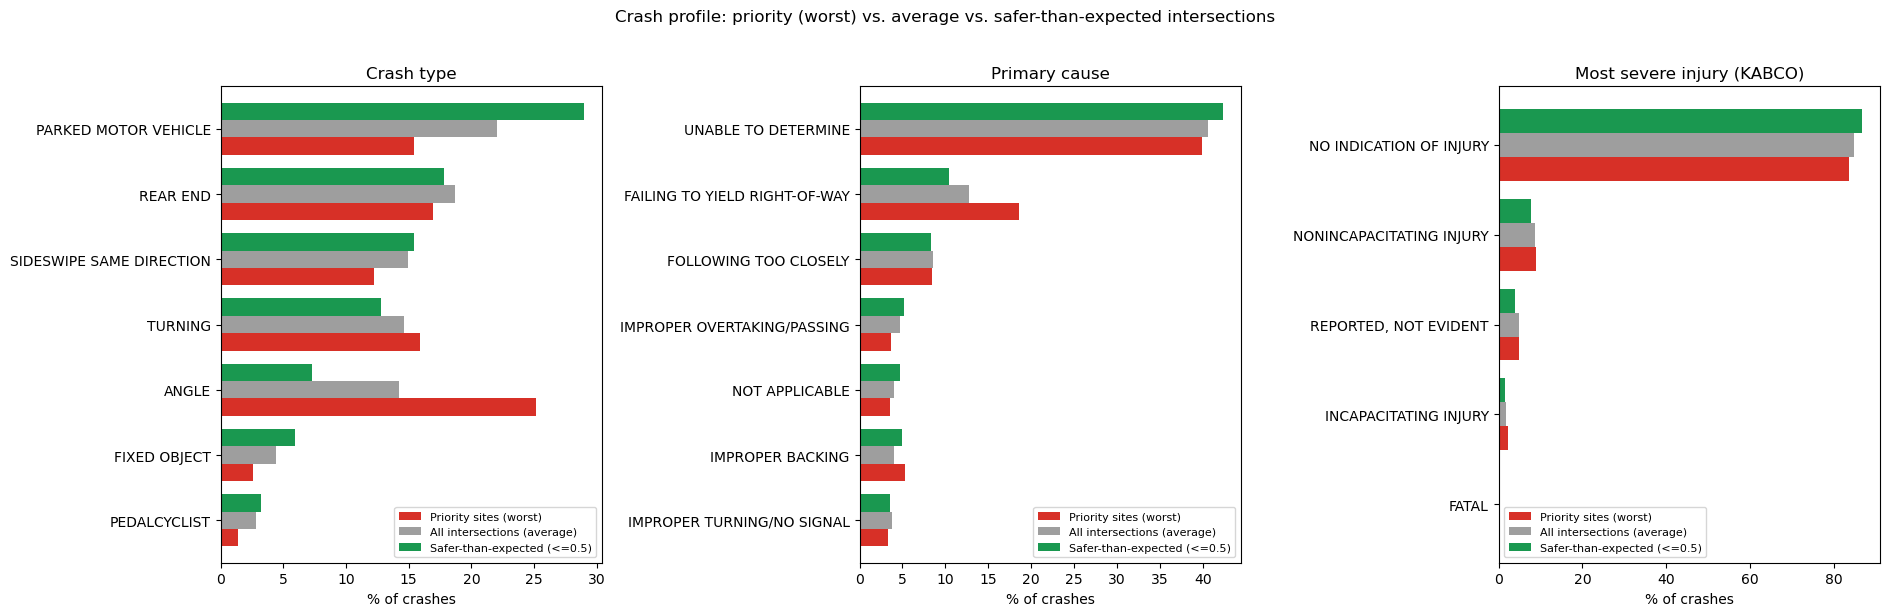

In [10]:
# Three pooled crash profiles (all use this notebook's Y-or-blank `assigned` set).
priority_nodes = sorted(set().union(*[s['nodes'] for s in systems]))
groups = {
    'Priority sites (worst)':       assigned[assigned['index_right'].isin(priority_nodes)],
    'All intersections (average)':  assigned,
    'Safer-than-expected (<=0.5)':  assigned[assigned['index_right'].isin(safe_nodes)],
}
print({k: len(v) for k, v in groups.items()})
colors = {'Priority sites (worst)': '#d73027', 'All intersections (average)': '#9e9e9e', 'Safer-than-expected (<=0.5)': '#1a9850'}

DIMS = [('FIRST_CRASH_TYPE', 'Crash type'), ('PRIM_CONTRIBUTORY_CAUSE', 'Primary cause'),
        ('MOST_SEVERE_INJURY', 'Most severe injury (KABCO)')]
fig, axes = plt.subplots(1, 3, figsize=(19, 6))
for ax, (col, title) in zip(axes, DIMS):
    cats = assigned[col].value_counts(normalize=True).head(7).index            # top categories overall
    comp = pd.DataFrame({g: gc[col].value_counts(normalize=True).reindex(cats).fillna(0) * 100
                         for g, gc in groups.items()})
    comp.index = [str(c)[:30] for c in comp.index]
    comp[list(groups)].iloc[::-1].plot(kind='barh', ax=ax, color=[colors[g] for g in groups], width=0.8)
    ax.set_title(title); ax.set_xlabel('% of crashes'); ax.legend(fontsize=8)
fig.suptitle('Crash profile: priority (worst) vs. average vs. safer-than-expected intersections', y=1.02)
plt.tight_layout(); plt.show()